In [303]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [304]:
import logging
logging.basicConfig(level=logging.INFO)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from gzjwst import chisq_utils

# from scipy.optimize import minimize

In [305]:
im = np.load('temp_detection_image.npy').astype(np.float32)  # saved as 64 but 0-1 range, 32 is fine
im.dtype

dtype('float32')

In [306]:
im.min(), im.max(), np.isnan(im).any()

(0.0, 1.0, False)

In [307]:
# TODO may need to save dof as well and only seg where max dof

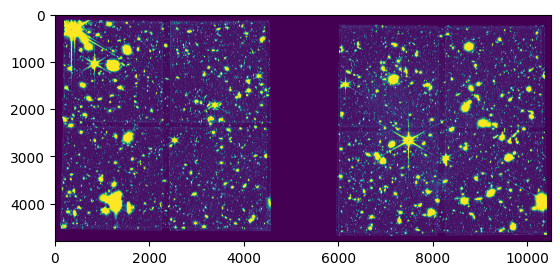

In [308]:
plt.imshow(im)

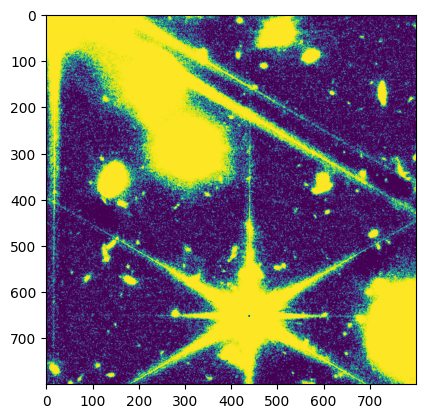

In [309]:
# im = im[2400:3400, 400:1200]
# im = im[400:1200, 2400:3400]
im = im[400:1200, 400:1200]
plt.imshow(im)

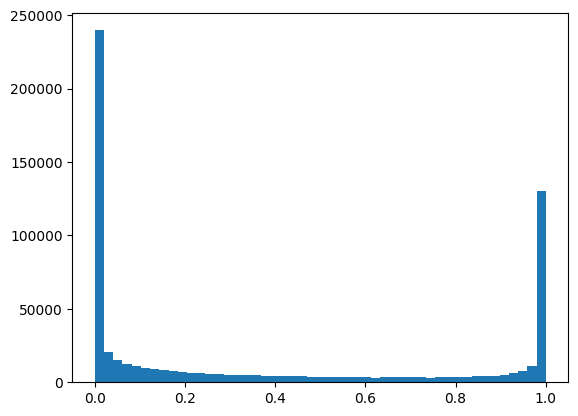

In [310]:
_ = plt.hist(im.flatten(), bins=np.linspace(0, 1))

In [311]:
from astropy.stats import SigmaClip
from photutils.background import MedianBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg = MedianBackground(sigma_clip)

In [312]:
bkg_value = bkg.calc_background(im)
print(bkg_value)

0.14917761


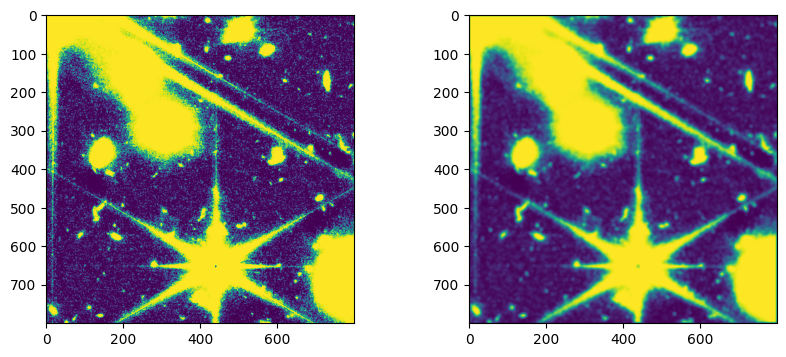

In [313]:
from astropy.convolution import convolve, Ring2DKernel
from photutils.segmentation import make_2dgaussian_kernel

kernel = Ring2DKernel(radius_in=0, width=5)
# kernel = make_2dgaussian_kernel(5.0, size=41)  # FWHM = 3.0

convolved_data = convolve(im, kernel)

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 4))
ax0.imshow(im)
ax1.imshow(convolved_data)

In [314]:
from photutils.segmentation import detect_sources

segment_map = detect_sources(convolved_data, threshold=.5, npixels=40)


In [315]:
from photutils.segmentation import deblend_sources

"""
converts the light in the image into trees, with branches representing bright areas within larger, fainter objects. 
Pixels in branches that contain at least a given proportion of the light of their parent objects are marked as individual objects, 
whilst branches containing a lower amount of light are regarded as part of the parent object
"""
# https://www.aanda.org/articles/aa/full_html/2021/01/aa36561-19/aa36561-19.html

segm_deblend = deblend_sources(convolved_data, segment_map,
                               npixels=40, nlevels=16, contrast=0.1, mode='sinh',
                               progress_bar=False)

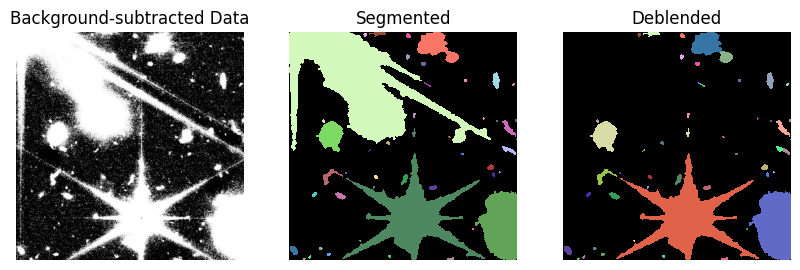

In [316]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 12.5))

ax0.imshow(im, cmap='Greys_r')
ax0.set_title('Background-subtracted Data')

ax1.imshow(segment_map, cmap=segment_map.cmap, interpolation='nearest')
ax1.set_title('Segmented')

ax2.imshow(segm_deblend, cmap=segment_map.cmap,
           interpolation='nearest')
ax2.set_title('Deblended')

for ax in (ax0, ax1, ax2):
    ax.axis('off')